In [1]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\91991\Desktop\internships\AMDOX\data\processed\daily_business_sales.csv"
)

df["date"] = pd.to_datetime(df["date"])

print(df.shape)

(1885, 22)


In [2]:
prophet_df = df[
    ["date", "sales"]
].rename(
    columns={
        "date": "ds",
        "sales": "y"
    }
)

In [7]:
train_df = prophet_df.iloc[:-30]

test_df = prophet_df.iloc[-30:]

print(train_df.shape)
print(test_df.shape)

(1855, 2)
(30, 2)


In [8]:
from prophet import Prophet

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

model.fit(train_df)

22:15:57 - cmdstanpy - INFO - Chain [1] start processing
22:15:58 - cmdstanpy - INFO - Chain [1] done processing


In [10]:
future = model.make_future_dataframe(
    periods=30
)

forecast = model.predict(future)

In [11]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

preds = forecast["yhat"].tail(30)

actuals = test_df["y"].values

mae = mean_absolute_error(
    actuals,
    preds
)

rmse = mean_squared_error(
    actuals,
    preds
) ** 0.5

print("MAE :", mae)
print("RMSE:", rmse)

MAE : 2637.5326274738704
RMSE: 3361.5140789466327


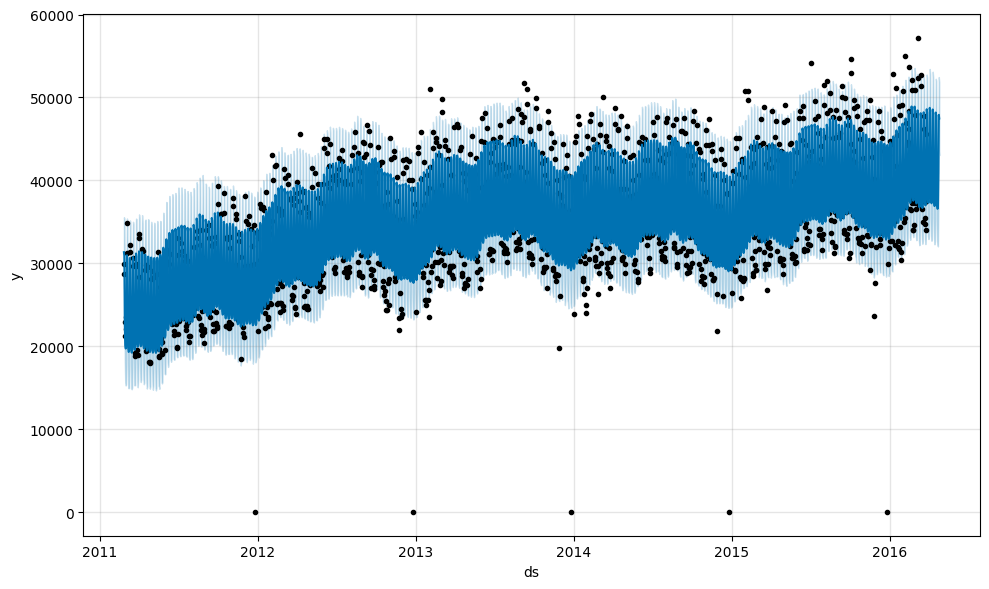

In [12]:
fig = model.plot(forecast)

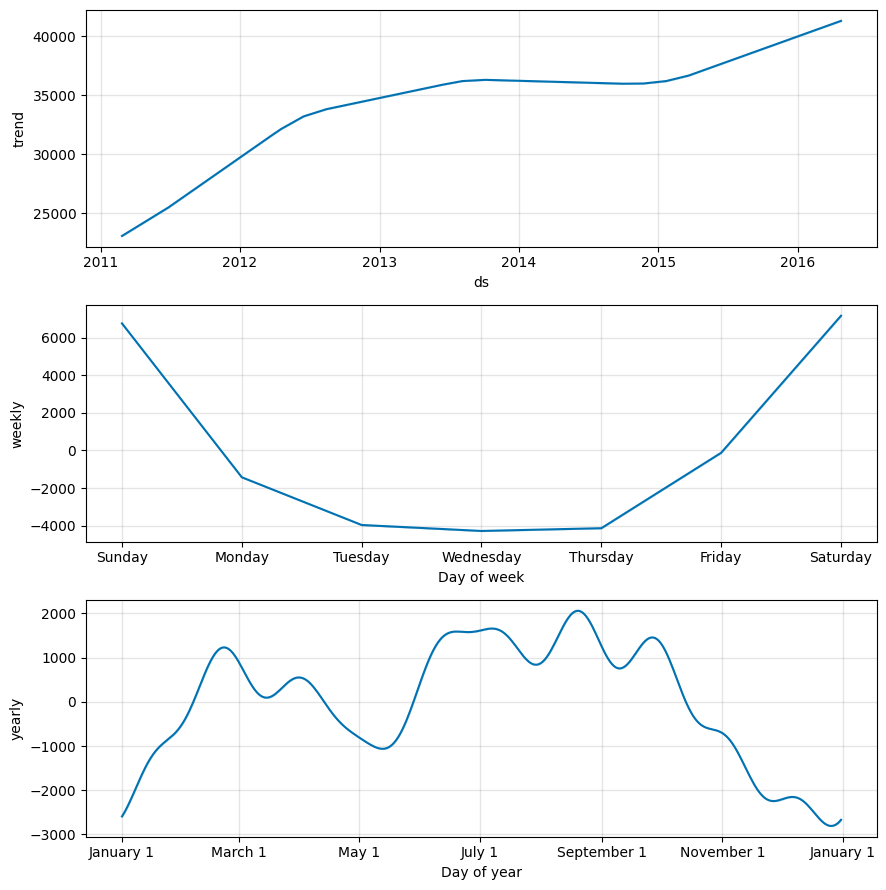

In [13]:
fig2 = model.plot_components(forecast)

In [14]:
forecast.to_csv(
    r"C:\Users\91991\Desktop\internships\AMDOX\data\processed\business_sales_forecast.csv",
    index=False
)

In [15]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(
    actuals,
    preds
) * 100

print(f"MAPE: {mape:.2f}%")

MAPE: 5.98%


In [16]:
print(df["sales"].describe())

count     1885.000000
mean     34461.923607
std       7305.360876
min         11.000000
25%      29780.000000
50%      33792.000000
75%      38902.000000
max      57218.000000
Name: sales, dtype: float64
